Author: Malcolm Zartman

Sharable Link: https://colab.research.google.com/drive/1_Z7CSfK10EDIz0zrHfFvK8NqHXttLAa5?usp=sharing

Model - Val Accuracy - Epoch

Dense - 84.11 - 2

CNN - 89.35 - 3

RNN - 81.00 - 4

RNN_Improve - 84.37 - 4


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 256)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,433 (2.76 MB)

 Trainable params: 722,433 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5283 - loss: 0.6976 - val_accuracy: 0.5287 - val_loss: 0.7042
Epoch 2/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5570 - loss: 0.6812 - val_accuracy: 0.5811 - val_loss: 0.6674
Epoch 3/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6916 - loss: 0.5817 - val_accuracy: 0.7196 - val_loss: 0.5496
Epoch 4/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7964 - loss: 0.4516 - val_accuracy: 0.8100 - val_loss: 0.4387
Epoch 5/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7533 - loss: 0.5031 - val_accuracy: 0.6452 - val_loss: 0.6191
Epoch 6/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7896 - loss: 0.4565 - val_accuracy: 0.6465 - val_loss: 0.6181
Epoch 7/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7504 - loss: 0.5026 - val_accuracy: 0.7644 - val_loss: 0.5258
Epoch 8/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8196 - loss: 0.4135 - val_acc

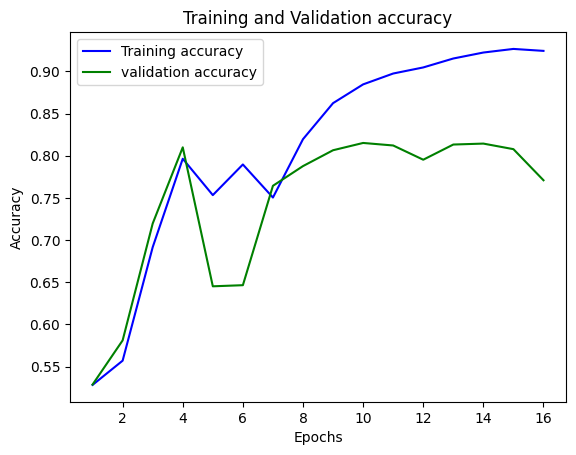

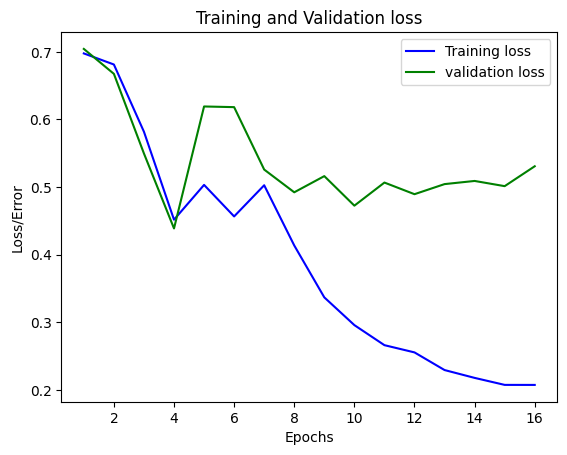

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


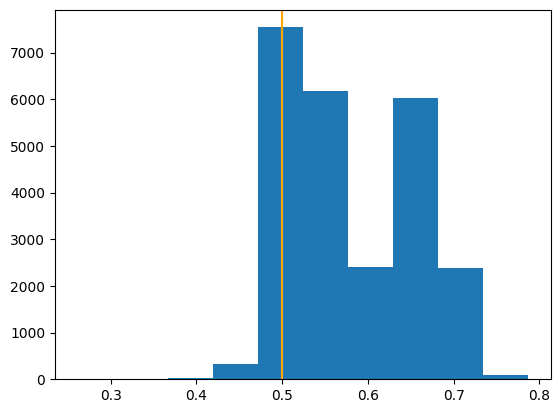

ROC-AUC Score: 56.39


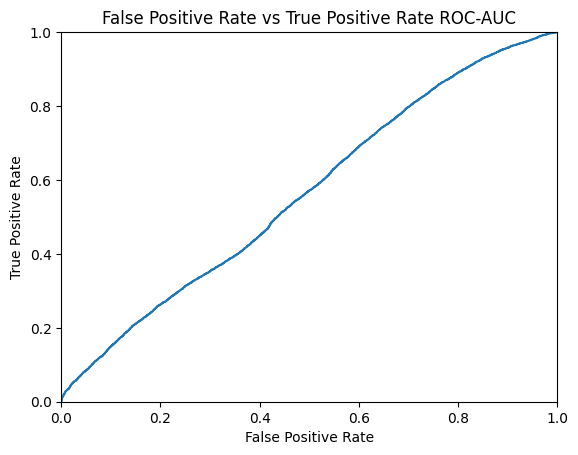

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding
from keras.layers import SpatialDropout1D, Conv1D, GlobalMaxPooling1D
from keras.layers import SimpleRNN # new!
from keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

###

# output directory name:
output_dir = 'model_output/rnn'

# training:
epochs = 16
batch_size = 128

# vector-space embedding:
n_dim = 64
n_unique_words = 10000
max_review_length = 100 # lowered due to vanishing gradient over time
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# RNN layer architecture: this recurrent layer has 256 units or 256 cells.
n_rnn = 256
drop_rnn = 0.2

###

# Load data
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words)

###

# Preprocess data
x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

###

# Design neural network architecture
model = Sequential()
# 1st hidden layer
model.add(Embedding(input_dim=n_unique_words, output_dim=n_dim, input_shape=(max_review_length,)))
model.add(SpatialDropout1D(drop_embed))
# 2nd hidden layer
model.add(SimpleRNN(n_rnn, dropout=drop_rnn))
# Output layer
model.add(Dense(1, activation='sigmoid'))

###

model.summary()

###

# Configure model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

###

modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/model_epoch_{epoch:05d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

###

# Train
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_valid, y_valid), callbacks=[modelcheckpoint])

###

# Evaluate - Accuracy
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs_range = range(1, epochs + 1)
plt.plot(epochs_range, loss_train, 'b', label='Training accuracy')
plt.plot(epochs_range, loss_val, 'g', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

###

# Evaluate - Loss
loss_train_l = history.history['loss']
loss_val_l = history.history['val_loss']
plt.plot(epochs_range, loss_train_l, 'b', label='Training loss')
plt.plot(epochs_range, loss_val_l, 'g', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

###

# Load best weights (Example assumes epoch 1 was the best, update the number based on your training results)
model.load_weights(output_dir+"/model_epoch_00001.keras")

y_hat = model.predict(x_valid)
plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')
plt.show()

###

print("ROC-AUC Score: {:0.2f}".format(roc_auc_score(y_valid, y_hat)*100.0))

fpr, tpr, thresholds = roc_curve(y_valid, y_hat)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

Training Improved Model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5874 - loss: 0.6554 - val_accuracy: 0.7060 - val_loss: 0.5768
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8034 - loss: 0.4346 - val_accuracy: 0.8288 - val_loss: 0.3967
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8491 - loss: 0.3524 - val_accuracy: 0.8244 - val_loss: 0.3915
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8695 - loss: 0.3107 - val_accuracy: 0.8437 - val_loss: 0.3672
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8811 - loss: 0.2924 - val_accuracy: 0.7556 - val_loss: 0.5038
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8555 - loss: 0.3361 - val_accuracy: 0.8375 - val_loss: 0.3835
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9117 - loss: 0.2300 - val_accuracy: 0.8324 - val_loss: 0.3967
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9253 - loss: 0.1988 - val_accuracy: 0.83

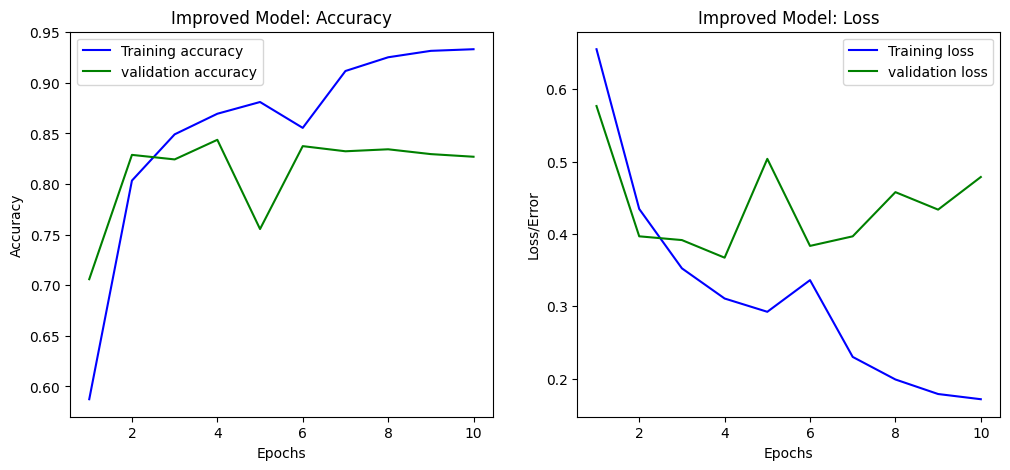

In [ ]:
# --- IMPROVED MODEL ---
# Updated hyperparameters to combat overfitting
output_dir_improved = 'model_output/rnn_improved'

epochs_improved = 10 # Reduced slightly as simple RNNs converge fast
batch_size_improved = 64 # Reduced batch size

n_dim = 64
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'

# Increased dropout rates
drop_embed_improved = 0.4
drop_rnn_improved = 0.4

# Reduced number of hidden units
n_rnn_improved = 64

# Design improved neural network architecture
improved_model = Sequential()
improved_model.add(Embedding(input_dim=n_unique_words, output_dim=n_dim, input_shape=(max_review_length,)))
improved_model.add(SpatialDropout1D(drop_embed_improved))
improved_model.add(SimpleRNN(n_rnn_improved, dropout=drop_rnn_improved))
improved_model.add(Dense(1, activation='sigmoid'))

improved_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

modelcheckpoint_improved = ModelCheckpoint(filepath=output_dir_improved+"/model_epoch_{epoch:05d}.keras")
if not os.path.exists(output_dir_improved):
    os.makedirs(output_dir_improved)

# Train Improved Model
print("Training Improved Model...")
history_improved = improved_model.fit(
    x_train, y_train,
    batch_size=batch_size_improved,
    epochs=epochs_improved,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[modelcheckpoint_improved]
)

# Evaluate Improved Model - Accuracy
loss_train_imp = history_improved.history['accuracy']
loss_val_imp = history_improved.history['val_accuracy']
epochs_range_imp = range(1, epochs_improved + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_imp, loss_train_imp, 'b', label='Training accuracy')
plt.plot(epochs_range_imp, loss_val_imp, 'g', label='validation accuracy')
plt.title('Improved Model: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Evaluate Improved Model - Loss
loss_train_l_imp = history_improved.history['loss']
loss_val_l_imp = history_improved.history['val_loss']

plt.subplot(1, 2, 2)
plt.plot(epochs_range_imp, loss_train_l_imp, 'b', label='Training loss')
plt.plot(epochs_range_imp, loss_val_l_imp, 'g', label='validation loss')
plt.title('Improved Model: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()